# Livrable 4 - Visualisation & API

Dans cette première partie du livrables nous allosn visualiser différentes données :
  * 1 ere visualisation : _Courbe des évolution des prix du marché_
  * 2 e   visualisation : _Distribution des prix au m2 (maison VS appartement)_
  * 3 e   visualisation : _Diagramme en barre des volumes mensuels_
  * 4 e   visualisation : _Une carte choroplèthe du prix au m2 par département_



Nous ne pouvons pas directement utiliser Spark pour visualiser nos différentes données. Nous devrons sélectionner une petite partie de nos données et les convertir en Pandas

In [7]:
# Initialisation Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, year, month

spark = (
    SparkSession.builder 
                .appName("Livrable4_Visualisations") 
                .getOrCreate()
)

print("Session Spark démarrée !")

fichiers_multiples = [f"../data/raw/dvf_full_{annee}.csv.gz" for annee in range(2021, 2025)]
df_enrichi = spark.read.csv(fichiers_multiples, header=True)


df_enrichi = df_enrichi.withColumn("prix_m2", col("valeur_fonciere").cast("double") / col("surface_reelle_bati").cast("double"))
df_enrichi = df_enrichi.filter((col("prix_m2") >= 100) & (col("prix_m2") <= 20000))

print("Données détaillées rechargées avec succès !")

df_enrichi.select("date_mutation", "valeur_fonciere", "prix_m2").show(5)

Session Spark démarrée !
Données détaillées rechargées avec succès !
+-------------+---------------+------------------+
|date_mutation|valeur_fonciere|           prix_m2|
+-------------+---------------+------------------+
|   2022-01-03|          55000|2291.6666666666665|
|   2022-01-03|         143000|1021.4285714285714|
|   2022-01-06|         255000|2361.1111111111113|
|   2022-01-03|         525000| 4166.666666666667|
|   2022-01-03|         525000|1238.2075471698113|
+-------------+---------------+------------------+
only showing top 5 rows


 ### Graphique Evolution des prix au m2 / Graphique Volume mensuels

Calcul de l'évolution annuelle en cours


/Users/baptistemathon/Documents/Next-U/N5/Python/FilRouge/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


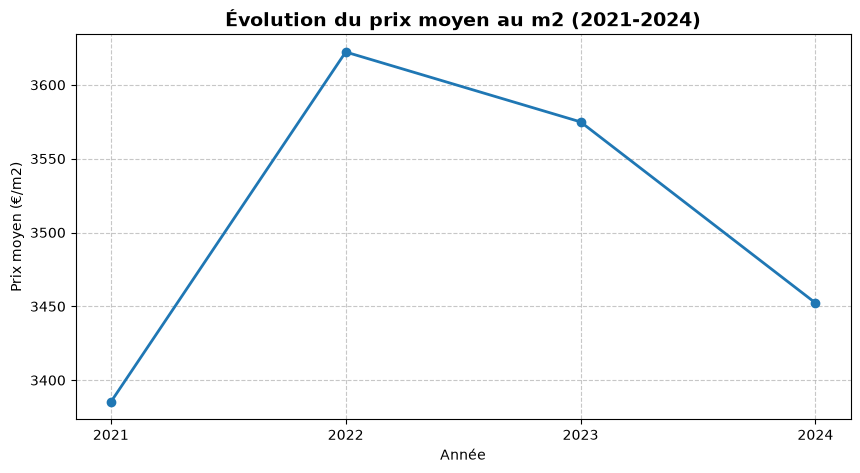

/Users/baptistemathon/Documents/Next-U/N5/Python/FilRouge/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Ce graphique montre l'évolution globale des prix de l'immobilier entre 2021 et 2024. Nous remarquons bien la baisse des prix sur les 2 dernières années
Calcul des volumes mensuels


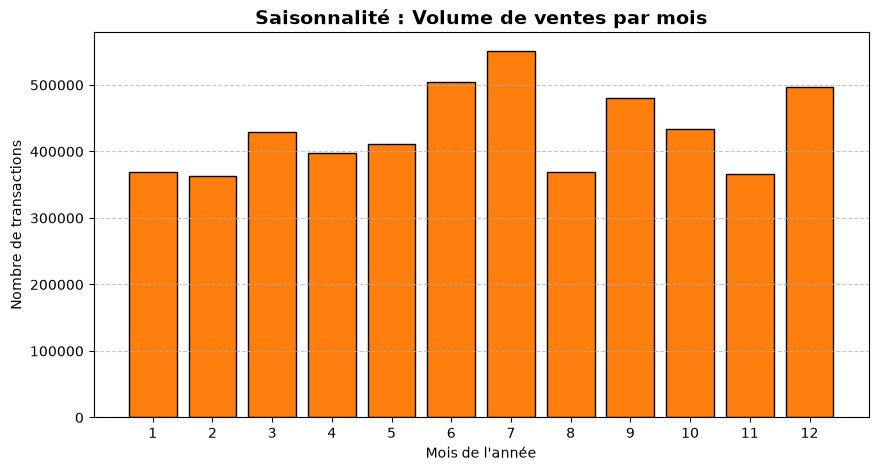

Sur ce graphique nous remarquons que les ventes mensuels stagne plus ou mois sur toute l'année à 350'000, hormis un pic sur les mois de juin et juillet


In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import year, month, avg

#-------------------------
# Evolution des prix au m2
#-------------------------
print("Calcul de l'évolution annuelle en cours")

df_annee = df_enrichi.withColumn("annee", year("date_mutation"))
evol_prix = df_annee.groupBy("annee").agg(avg("prix_m2").alias("prix_moyen")).orderBy("annee").toPandas()

# Graphique : 
plt.figure(figsize=(10, 5))
plt.plot(evol_prix["annee"], evol_prix["prix_moyen"], marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.title("Évolution du prix moyen au m2 (2021-2024)", fontsize=14, fontweight='bold')
plt.xlabel("Année")
plt.ylabel("Prix moyen (€/m2)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(evol_prix["annee"]) 
plt.show()

print("Ce graphique montre l'évolution globale des prix de l'immobilier entre 2021 et 2024. Nous remarquons bien la baisse des prix sur les 2 dernières années")


#-----------------
# Volumes mensuels
#-----------------

print("Calcul des volumes mensuels")

df_mois = df_enrichi.withColumn("mois", month("date_mutation"))
vol_mois = df_mois.groupBy("mois").count().orderBy("mois").toPandas()

# Graphique :
plt.figure(figsize=(10, 5))
plt.bar(vol_mois["mois"], vol_mois["count"], color='#ff7f0e', edgecolor='black')
plt.title("Saisonnalité : Volume de ventes par mois", fontsize=14, fontweight='bold')
plt.xlabel("Mois de l'année")
plt.ylabel("Nombre de transactions")
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Sur ce graphique nous remarquons que les ventes mensuels stagne plus ou mois sur toute l'année à 4000'000, hormis un pic sur les mois de juin, juillet, septembre et décembre vers 500'000")

### Visualtion de la distribution Maison VS Appartement

/Users/baptistemathon/Documents/Next-U/N5/Python/FilRouge/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/var/folders/xs/jrs1y89110jbdw4ctm6lbc4c0000gn/T/ipykernel_2382/3155884226.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x="type_local", y="prix_m2", palette="Set2")


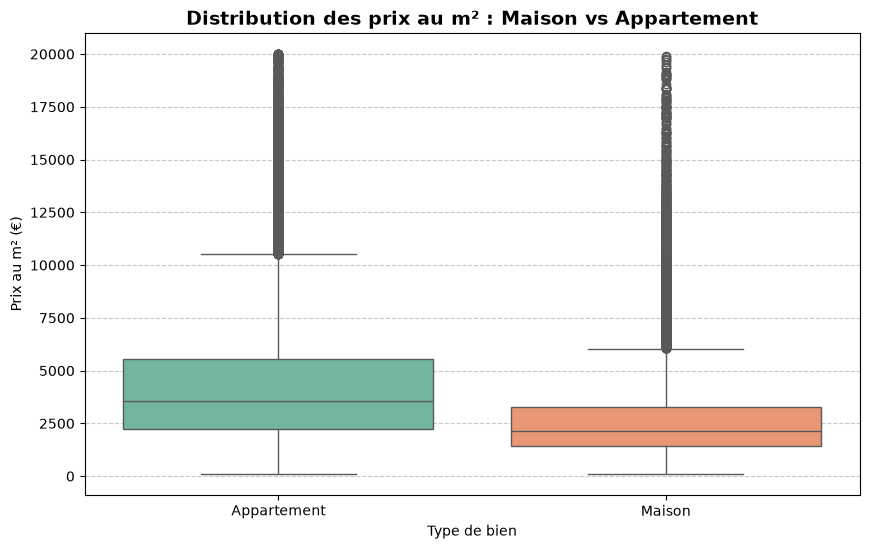

Grâce à ce graphique, on constate que le prix médian au m2 des appartements est plus élevée que celui des maisons. 

Ceci peu s'expliquer car les appartements se trouvent principalement dans les grandes villes où le mètre carré est plus élevé


In [14]:
import seaborn as sns


#------------------------------------
# Visualisation Maison VS appartement
#------------------------------------

# Récupération d'une petite partie des données pour les convertir en pandas
df_sample = (df_enrichi.filter(col("type_local").isin("Maison", "Appartement"))
                       .sample(fraction=0.01, seed=42)
                       .select("type_local", "prix_m2")
                       .toPandas())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sample, x="type_local", y="prix_m2", palette="Set2")
plt.title("Distribution des prix au m² : Maison vs Appartement", fontsize=14, fontweight='bold')
plt.xlabel("Type de bien")
plt.ylabel("Prix au m² (€)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"""Grâce à ce graphique, on constate que le prix médian au m2 des appartements est plus élevée que celui des maisons. \n
Ceci peu s'expliquer car les appartements se trouvent principalement dans les grandes villes où le mètre carré est plus élevé""")

### Visualtion d'une Carte Choroplèthe des prix par département

In [17]:
import folium

#-------------------------------------------
# Carte Choroplèthe des prix par département
#-------------------------------------------

df_dept = df_enrichi.dropna(subset=["code_departement"]) \
                    .groupBy("code_departement") \
                    .agg(avg("prix_m2").alias("prix_moyen")) \
                    .toPandas()


df_dept["code_departement"] = df_dept["code_departement"].astype(str).str.zfill(2)

# URL publique contenant le dessin des départements français
url_geojson_fr = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"

carte_france = folium.Map(location=[46.2276, 2.2137], zoom_start=6)

folium.Choropleth(
    geo_data=url_geojson_fr,
    name="choropleth",
    data=df_dept,
    columns=["code_departement", "prix_moyen"],
    key_on="feature.properties.code",
    fill_color="YlOrRd", # Couleurs de Jaune à Rouge
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Prix moyen au m² (€)"
).add_to(carte_france)

# Sauvegarfe de la carte de France
carte_france.save("../data/carte_prix_m2_france.html")
print("-- Carte de France des prix par département sauvegardé")

print(""" \nLa carte de France met en évidence les grosses différences de prix selon les régions \n
On repère vite les zones les plus chères comme : l'Ile de France et la côté d'Azur
""")

/Users/baptistemathon/Documents/Next-U/N5/Python/FilRouge/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


-- Carte de France des prix par département sauvegardé
 
La carte de France met en évidence les grosses différences de prix selon les régions 

On repère vite les zones les plus chères comme : l'Ile de France et la côté d'Azur



26/09/10 00:37:59 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1026076 ms exceeds timeout 120000 ms
26/09/10 00:37:59 WARN SparkContext: Killing executors is not supported by current scheduler.
26/09/10 00:50:54 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:34)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.stor